# CLIP + MNIST: eksperymenty zero-shot
Ten notatnik pozwala porownywac modele CLIP na cyfrach MNIST z roznymi promptami tekstowymi.
Uruchamiaj komorki od gory do dolu. Zmien parametry w nastepnej komorce i uruchom eksperyment ponownie.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import clip
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
 )
from torch.utils.data import DataLoader, Subset
from torchvision import datasets

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Wykryte urzadzenie: {DEVICE.upper()}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# lista dostepnych modeli CLIP
MODELS = [
    "RN50",
    "RN101",
    "RN50x4",
    "RN50x16",
    "RN50x64",
    "ViT-B/32",
    "ViT-B/16",
    "ViT-L/14",
    "ViT-L/14@336px",
]

# krotkie opisy modeli CLIP
MODEL_DESCRIPTIONS = {
    "RN50": "Backbone ResNet-50; najszybszy i najmniejszy w rodzinie RN.",
    "RN101": "Backbone ResNet-101; wieksza pojemnosc niz RN50.",
    "RN50x4": "Szerszy RN50; lepsza jakosc, wolniejszy.",
    "RN50x16": "Znacznie szerszy RN50; wysoka jakosc, duzy koszt obliczen.",
    "RN50x64": "Najwiekszy wariant RN; najwyzszy koszt obliczen.",
    "ViT-B/32": "Vision Transformer base z patchami 32px; dobry kompromis szybkosci i jakosci.",
    "ViT-B/16": "Vision Transformer base z patchami 16px; bardziej dokladny, wolniejszy.",
    "ViT-L/14": "Duzy ViT z patchami 14px; wysoka jakosc, duzy koszt obliczen.",
    "ViT-L/14@336px": "ViT-L/14 z wejsciem 336px; najlepsza jakosc, najwolniejszy.",
}

Wykryte urzadzenie: CPU


In [3]:
MODEL_NAME = "ViT-B/32"  # wybierz z MODELS
PROMPT_STYLE = "photo_digit"  # opcje: digit, number_word, digit_word, photo_digit, photo_digit_word
NUM_SAMPLES = None  # ustaw None, aby ocenic caly test
BATCH_SIZE = 64

# katalog na dane MNIST z numerami
MNIST_ROOT = Path.cwd().parent / "images"

DATASET_SPLIT = "test"  # MNIST ma tylko train/test

## Uruchom ewaluacje
Po zmianie parametrow powyzej uruchom ponownie te sekcje i metryki ponizej.

In [ ]:
# slowne nazwy cyfr
NUMBERS_WRITTEN = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]

PROMPT_TEMPLATES = {
    "digit": "{i}",
    "number_word": "number {word}",
    "digit_word": "digit {i}",
    "photo_digit": "a photo of a number {i}",
    "photo_digit_word": "a photo of a number {word}"
}

# funkcja budujaca etykiety dla cyfr
def build_labels(prompt_style):
    if prompt_style not in PROMPT_TEMPLATES:
        raise ValueError(f"Nieznany PROMPT_STYLE: {prompt_style}")
    template = PROMPT_TEMPLATES[prompt_style]
    labels = []
    for i in range(10):
        labels.append(template.format(i=i, word=NUMBERS_WRITTEN[i]))
    return labels

# funkcja pobierajaca MNIST. Wybiera 'train' i pobiera dane jesli brak
def get_mnist(split):
    is_train = split == "train"
    return datasets.MNIST(root=MNIST_ROOT, train=is_train, download=True)

# wlasny collate dla DataLoader. Rozdziela obrazy i etykiety.
def pil_collate(batch):
    images, targets = zip(*batch)
    return list(images), torch.tensor(targets)

# tworzy DataLoader
def make_loader(dataset, num_samples, batch_size):
    if num_samples is None or num_samples >= len(dataset):
        subset = dataset
    else:
        indices = np.random.choice(len(dataset), size=num_samples, replace=False)
        subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=False, collate_fn=pil_collate)

# glowna ewaluacja CLIP
def run_clip_eval(model, preprocess, labels, loader, device):
    # Tokenizacja etykiet tekstowych
    text_tokens = clip.tokenize(labels).to(device)

    # Ustawienie trybu eval i policzenie cech tekstu tylko raz
    model.eval()
    with torch.no_grad():
        text_features = model.encode_text(text_tokens).float()
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    # Przygotowanie pojemnikow na wyniki
    all_preds = []
    all_targets = []
    all_probs = []

    # Petla po batchach bez gradientow
    with torch.no_grad():
        for images, targets in loader:
            # Preprocess kazdego obrazu i zlozenie batcha
            processed_images = []
            for img in images:
                rgb_img = img.convert("RGB")
                processed = preprocess(rgb_img)
                processed_images.append(processed)
            image_inputs = torch.stack(processed_images).to(device)

            # Jawne wyliczenie cech obrazu
            image_features = model.encode_image(image_inputs).float()
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            # Logity podobienstwa obraz-tekst
            logit_scale = model.logit_scale.exp()
            logits_per_image = logit_scale * image_features @ text_features.T
            logits_per_text = logits_per_image.T

            # Zamiana logitow na prawdopodobienstwa i predykcje
            probs = logits_per_image.softmax(dim=-1).cpu().numpy()
            preds = probs.argmax(axis=-1)

            # Zapis wynikow dla tego batcha
            all_preds.extend(preds.tolist())
            all_targets.extend(targets.tolist())
            all_probs.append(probs)

    # Zwrot wynikow w postaci tablic NumPy
    return np.array(all_preds), np.array(all_targets), np.vstack(all_probs)

In [5]:

if MODEL_NAME not in MODELS:
    raise ValueError(f"MODEL_NAME musi byc jednym z: {MODELS}")

labels = build_labels(PROMPT_STYLE)
print("Etykiety:", labels)

dataset = get_mnist(DATASET_SPLIT)
loader = make_loader(dataset, NUM_SAMPLES, BATCH_SIZE)

model, preprocess = clip.load(MODEL_NAME, device=DEVICE)

preds, targets, probs = run_clip_eval(model, preprocess, labels, loader, DEVICE)
print(f"Liczba ocenionych probek: {len(targets)}")

Etykiety: ['a photo of a number 0', 'a photo of a number 1', 'a photo of a number 2', 'a photo of a number 3', 'a photo of a number 4', 'a photo of a number 5', 'a photo of a number 6', 'a photo of a number 7', 'a photo of a number 8', 'a photo of a number 9']


100%|███████████████████████████████████████| 338M/338M [05:46<00:00, 1.02MiB/s]


Liczba ocenionych probek: 10000


## Metryki i analiza
Accuracy, confusion matrix, precision i recall dla kazdej cyfry.

Accuracy: 0.2464


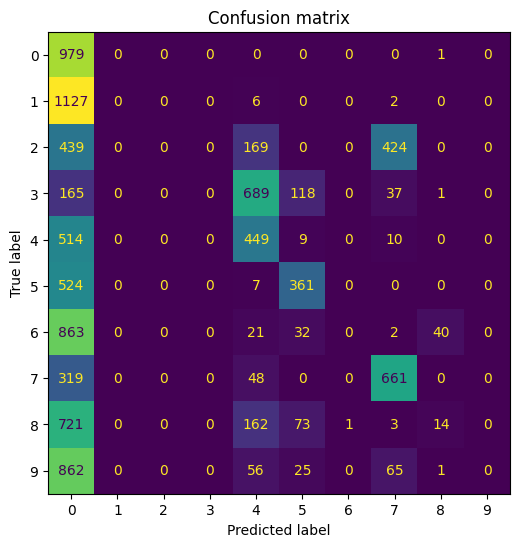

Cyfra 0: precision=0.150, recall=0.999, f1=0.261, support=980
Cyfra 1: precision=0.000, recall=0.000, f1=0.000, support=1135
Cyfra 2: precision=0.000, recall=0.000, f1=0.000, support=1032
Cyfra 3: precision=0.000, recall=0.000, f1=0.000, support=1010
Cyfra 4: precision=0.279, recall=0.457, f1=0.347, support=982
Cyfra 5: precision=0.584, recall=0.405, f1=0.478, support=892
Cyfra 6: precision=0.000, recall=0.000, f1=0.000, support=958
Cyfra 7: precision=0.549, recall=0.643, f1=0.592, support=1028
Cyfra 8: precision=0.246, recall=0.014, f1=0.027, support=974
Cyfra 9: precision=0.000, recall=0.000, f1=0.000, support=1009

Pelny raport klasyfikacji:
              precision    recall  f1-score   support

           0      0.150     0.999     0.261       980
           1      0.000     0.000     0.000      1135
           2      0.000     0.000     0.000      1032
           3      0.000     0.000     0.000      1010
           4      0.279     0.457     0.347       982
           5      0.58

In [60]:
# Metryki: accuracy, confusion matrix, precision, recall per klasa
acc = accuracy_score(targets, preds)
print(f"Accuracy: {acc:.4f}")

cm = confusion_matrix(targets, preds, labels=list(range(10)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Confusion matrix")
plt.show()

prec, rec, f1, support = precision_recall_fscore_support(
    targets, preds, labels=list(range(10)), zero_division=0
 )
for i in range(10):
    print(
        f"Cyfra {i}: precision={prec[i]:.3f}, recall={rec[i]:.3f}, " # type: ignore
        f"f1={f1[i]:.3f}, support={support[i]}" # type: ignore
    )

print("\nPelny raport klasyfikacji:")
print(classification_report(targets, preds, labels=list(range(10)), digits=3, zero_division=0))

## Inspekcja pojedynczego przykladu
Opcjonalnie: zobacz jeden przyklad i prawdopodobienstwa modelu.

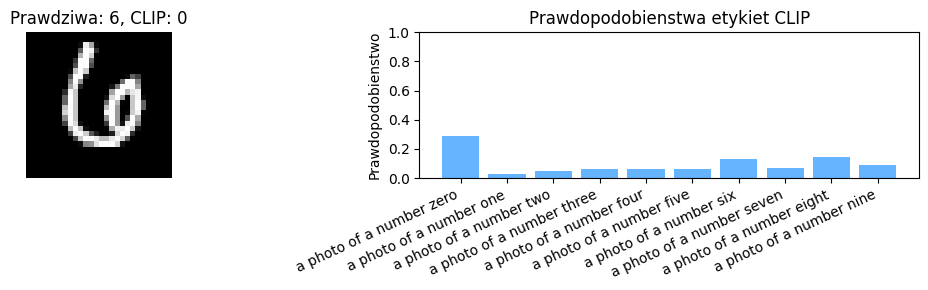

In [ ]:
# Inspekcja pojedynczego losowego przykladu
mnist_size = len(dataset)
idx = random.randrange(0, mnist_size)
sample_img, sample_target = dataset[idx]
image_input = preprocess(sample_img.convert("RGB")).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    logits_per_image, _ = model(image_input, clip.tokenize(labels).to(DEVICE))
    probs_single = logits_per_image.softmax(dim=-1).cpu().numpy()[0]
    pred_idx = int(probs_single.argmax())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))
ax1.imshow(sample_img, cmap="gray")
ax1.set_title(f"Prawdziwa: {sample_target}, CLIP: {pred_idx}")
ax1.axis("off")

ax2.bar(range(len(labels)), probs_single, color="#66b3ff")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=25, ha="right")
ax2.set_ylabel("Prawdopodobienstwo")
ax2.set_ylim(0, 1)
ax2.set_title("Prawdopodobienstwa etykiet CLIP")

plt.tight_layout()
plt.show()

## Wnioski dla CLIP z MNIST
Mimo że CLIP to potężny model wielomodalny trenowany na 400 milionach par danych, jego skuteczność na zbiorze MNIST (zero-shot) jest drastycznie niska (często poniżej 50%, a przy złym prompcie spada do 10-20%). Dla porównania, prosta klasyczna regresja logistyczna osiąga tu ~92%, a sieci CNN ponad 99%.

Tak słabe wyniki mogą wynikać z kilku konkretnych ograniczeń architektury modelu:
- CLIP uczył się na naturalnych zdjęciach o bogatym kontekście (cienie, oświetlenie, tła). Sterylne, czarno-białe cyfry MNIST bez tła są dla niego nienaturalną, "mechaniczną" anomalią, którą warstwy uwagi często traktują jako bezwartościowy szum.
- Pojęcia leksykalne są zbyt ogólnikowe. Słowo (np. "siedem") nie posiada wystarczającej precyzji, aby zamapować w funkcji kosinusowej drobne różnice geometryczne i topograficzne odręcznych krzywizn pętli.
- Model wyewoluował w oparciu o silną wiarę w tekst obecny na obrazach, co czyni go podatnym na "Błąd Abstrakcji" i ataki typograficzne. Kiedy abstrakcyjny symbol arytmetyczny zostaje wyrwany z jakiegokolwiek szerszego kontekstu semantycznego, model traci ramy interpretacyjne i zaczyna zgadywać.  

## 2. Próbkowanie Liniowe (Linear Probing)

### Czym jest Próbkowanie Liniowe?
Próbkowanie liniowe (ang. *linear probing*) to technika polegająca na rezygnacji z klasyfikatora tekstowo-obrazowego na rzecz wykorzystania wewnętrznych struktur modelu jako generatora wektorów reprezentacji głębokiej przestrzeni. W tym paradygmacie zamraża się oryginalne wagi modelu wizyjnego, a na szczycie uzyskanych osadzeń (embeddings) implementuje się i trenuje prostą warstwę klasyfikatora liniowego.

### Co robi poniższy kod?
1. **Ekstrakcja cech wizualnych:** Przepuszcza obrazy z sekcji treningowej oraz testowej zbioru MNIST przez zablokowany koder obrazu CLIP, ekstrahując z nich znormalizowane wektory głębokich reprezentacji.
2. **Trening głowicy liniowej:** Wykorzystuje uzyskane wektory do wytrenowania tradycyjnego modelu regresji logistycznej, który uczy się separacji statystycznej i wyznaczania płaszczyzn decyzyjnych dla 10 klas odręcznych cyfr.
3. **Ewaluacja i porównanie:** Generuje ostateczne predykcje dla zbioru testowego oraz wyświetla pełen raport klasyfikacji, pozwalając na bezpośrednie, empiryczne zweryfikowanie wzrostu skuteczności po odcięciu ograniczeń semantyki języka naturalnego.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import torch

# ekstrakcja wektorów cech z modelu CLIP
def extract_clip_features(loader, model, preprocess, device):
    """
    Przepuszcza obrazy przez koder obrazu CLIP i zwraca wektory cech (embeddings)
    bez udziału kodera tekstu.
    """
    all_features = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for images, targets in loader:
            # Preprocess i budowa wejścia
            processed_images = [preprocess(img.convert("RGB")) for img in images]
            image_inputs = torch.stack(processed_images).to(device)

            # Ekstrakcja cech z kodera obrazu
            image_features = model.encode_image(image_inputs).float()
            # Normalizacja wektorów
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            all_features.append(image_features.cpu().numpy())
            all_labels.extend(targets.tolist())

    return np.vstack(all_features), np.array(all_labels)

# Pobranie zbioru treningowego i utworzenie loaderów
train_dataset = get_mnist("train")

train_loader = make_loader(train_dataset, num_samples=10000, batch_size=BATCH_SIZE)

test_loader = loader 

# Ekstrakcja cech głębokich
X_train, y_train = extract_clip_features(train_loader, model, preprocess, DEVICE)

X_test, y_test = extract_clip_features(test_loader, model, preprocess, DEVICE)

# Trening klasyfikatora liniowego (Linear Probing)
classifier = LogisticRegression(random_state=SEED, max_iter=1000, C=0.316)
classifier.fit(X_train, y_train)

# Ewaluacja metody Linear Probing
predictions = classifier.predict(X_test)
acc_linear = accuracy_score(y_test, predictions)

print(f"Dokładność (Accuracy): {acc_linear:.4f}")
print("Szczegółowy raport:")
print(classification_report(y_test, predictions, digits=3))

Pobieranie i przygotowanie zbioru treningowego MNIST...
Ekstrakcja wektorów cech dla zbioru treningowego (to może chwilę potrwać)...
Ekstrakcja wektorów cech dla zbioru testowego...
Rozpoczęcie trenowania regresji logistycznej na cechach CLIP...
\n=== Wyniki eksperymentu Linear Probing ===
Dokładność (Accuracy): 0.8822
\nSzczegółowy raport:
              precision    recall  f1-score   support

           0      0.900     0.984     0.940       980
           1      0.907     0.982     0.943      1135
           2      0.871     0.805     0.837      1032
           3      0.833     0.864     0.848      1010
           4      0.921     0.909     0.915       982
           5      0.884     0.842     0.862       892
           6      0.891     0.879     0.885       958
           7      0.884     0.845     0.864      1028
           8      0.813     0.861     0.836       974
           9      0.920     0.837     0.877      1009

    accuracy                          0.882     10000
   macr

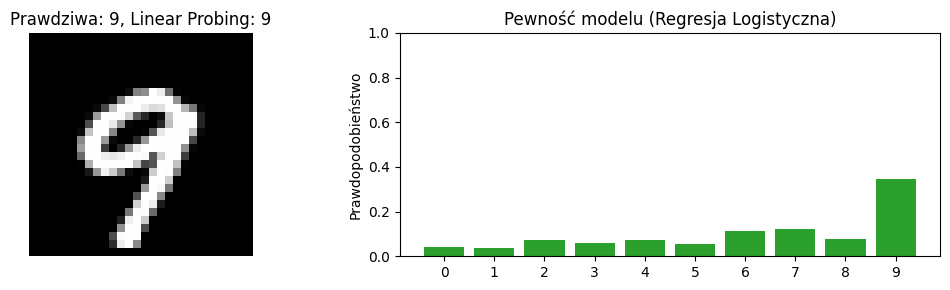

In [ ]:
# Losowanie indeksu ze zbioru testowego
idx = random.randrange(0, len(dataset))
sample_img, sample_target = dataset[idx]

# Ekstrakcja cechy dla pojedynczego obrazka za pomocą zamrożonego kodera CLIP
image_input = preprocess(sample_img.convert("RGB")).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    image_feature = model.encode_image(image_input).float()
    # Normalizacja wektora (zgodnie z wcześniejszymi krokami)
    image_feature = image_feature / image_feature.norm(dim=-1, keepdim=True)
    image_feature_np = image_feature.cpu().numpy()

# Predykcja za pomocą wyuczonego modelu regresji logistycznej
pred_idx = classifier.predict(image_feature_np)[0]
probs_single = classifier.predict_proba(image_feature_np)[0]

# Wizualizacja graficzna
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))
ax1.imshow(sample_img, cmap="gray")
ax1.set_title(f"Prawdziwa: {sample_target}, Linear Probing: {pred_idx}")
ax1.axis("off")

# Rysowanie rozkładu prawdopodobieństwa z regresji logistycznej
ax2.bar(range(10), probs_single, color="#2ca02c")
ax2.set_xticks(range(10))
ax2.set_xticklabels([str(i) for i in range(10)])
ax2.set_ylabel("Prawdopodobieństwo")
ax2.set_ylim(0, 1)
ax2.set_title("Pewność modelu (Regresja Logistyczna)")

plt.tight_layout()
plt.show()

## Wnioski dla Linear Probing z MNIST

Zastosowanie próbkowania liniowego zazwyczaj poprawia wyniki względem trybu zero-shot, jednak ten eksperyment obnaża kolejne, głęboko zakorzenione słabości architektury CLIP w starciu z izolowaną geometrią
- Wytrenowanie warstwy regresji liniowej na zamrożonych osadzeniach wizualnych modelu pozwala odciąć zawodny koder tekstowy . Eliminuje to problem "wąskiego gardła" i niestabilności szablonów, stabilizując predykcję na wyższym poziomie.
- Takie podejście jest kompromisem polegającym na powrocie do uczenia nadzorowanego z użyciem etykiet. Model w ten sposób traci swoją największą zaletę decyzyjną - swoją zdolność do adaptacji w locie.
- Mimo zmiany podejścia i poprawienia wyników klasyfikacji, cechy wyciągnięte z CLIP-a nadal wypadają blado w zestawieniu z architekturą sieci splotowych (CNN), a nawet z podstawową regresją logistyczną na surowych pikselach . Udowadnia to trwalszy defekt: koder obrazu CLIP, ukształtowany ewolucyjnie przez organiczną semantykę internetową, trwale zniekształca obiektywną, dyskryminacyjną optykę i gubi ścisłe relacje pikslowe izolowanych brył.